# Noise and signal correlation in simultaneously recorded selective pairs

## Introduction

A single neuron's firing rate says what that neuron encodes. It says nothing
about whether neurons act together — and coordinated activity between neurons
carries information that neither carries alone, gates what downstream targets
receive, and changes with behavioural state even when firing rates do not.

Two neurons recorded at the same time can be related in two distinct ways, and
conflating them is the standard error in this literature.

**Signal correlation** is similarity of *tuning*. If two neurons both respond to
fixation onset with the same time course, their trial-averaged responses
resemble each other. This is a statement about what the two cells encode, and it
survives averaging: it is visible in the mean response and requires no
simultaneous recording in principle.

**Noise correlation** is trial-by-trial *covariation*. If, on the fixations where
one neuron happens to fire more, the other does too, then beyond what their
average profiles predict, the two co-fluctuate. This requires simultaneous
recording by definition, and averaging destroys it.

The two are formally independent. Two neurons can have identical mean responses
and be statistically independent trial to trial; two neurons with unrelated
tuning can co-fluctuate tightly through shared input. Which of the two a
behavioural variable modulates is therefore a substantive question, not a
technicality — modulating shared tuning means the population's *representation*
changes, while modulating co-fluctuation means its *noise structure* changes,
and these have opposite consequences for how much information the population
carries.

This chapter asks which of the two, if either, distinguishes **interactive-face**
fixations from non-interactive-face and object fixations, in each of four
regions — BLA, ACCg, dmPFC and OFC — and across the region pairs the recordings
support.

### What is asked

1. Is there signal correlation between simultaneously recorded selective pairs,
   beyond what any two units of the same region show?
2. Does it depend on the fixation condition?
3. Is there noise correlation beyond what each unit's own fixation-locked rate
   profile predicts?
4. Does *that* depend on the fixation condition?
5. Are the two related — do pairs with shared tuning also co-fluctuate?
6. Does any of this extend across regions?

## Methods

### Recordings and units

Single units were recorded simultaneously from BLA, ACCg, dmPFC and OFC while
two macaques viewed each other and non-social objects. Analysis is restricted to
**FDR-corrected selective units** — units significantly selective for at least
one fixation-condition contrast in the single-unit analysis
(`three_condition_core` family). Two justifications: a unit with no reliable
fixation response contributes a mean timeline that is mostly estimation noise,
and correlating noise with noise adds variance and nothing else; and the
question *do units that respond to fixation condition share response structure*
presupposes units that respond.

Every pair analysed is **two selective units recorded in the same session**, so
both measures are defined on the same pairs and can be compared pair for pair.

### Fixation conditions

Three conditions throughout, matching the single-unit and population analyses so
results can be joined without translation:

- **interactive face** — face fixations during interactive periods
- **non-interactive face** — face fixations outside them
- **object** — object fixations, pooled across interactive state

### Analysis window

All correlations use spikes within **±500 ms of fixation onset**, in 1 ms bins,
**unsmoothed**. Smoothing before cross-correlation blurs exactly the fine timing
the noise measure exists to detect. The window is not widened: 95% of ±5 s
surrounds contain at least one other analysed fixation (median 5), so data
outside it is not neutral baseline.

### Noise correlation

For each pair and condition, the cross-correlation is computed on **one
fixation's two spike trains** and only then averaged across fixations.
Cross-correlating condition-averaged PSTHs would measure shared rate structure
rather than co-firing.

The correlation is **linear** (zero-padded transform) — the statistic
`scipy.signal.correlate` computes, and the one the behavioural
cross-correlations in this thesis use. At lag *L* only the *N* − |*L*|
overlapping bins contribute, so no spike is ever paired with one a full window
away. Values are therefore unnormalised: at each 1 ms lag the correlation is the
number of spike pairs separated by that lag, per fixation, and chance is
approximately rate₁ × rate₂ × bin width.

**Null: circular shift.** One unit's train is rotated by a random offset of at
least 50 ms *within its own fixation*, and the pair re-correlated; 50 draws are
averaged. Each fixation retains its own spike count and slow envelope, so two
cells whose excitability merely rises and falls together across fixations
produce no excess. Only fine temporal alignment is destroyed.

A cross-trial shuffle was considered and rejected as the primary null. It pairs
unit A's fixation *i* with unit B's fixation *j*, destroying across-fixation rate
covariation as well as timing, which makes it too low a bar: a synthetic pair
built with shared gain and no timing relationship at all reaches *z* = 2.0
against it and 1.3 against the circular shift, level with an uncoupled pair. It
is computed alongside and stored; the condition contrasts are the same under
either to the third decimal, because a within-pair condition difference is a
difference of two excesses and the null largely cancels.

**Trial-count matching.** Interactive-face fixations outnumber the others roughly
six to one. Since a null-corrected excess is estimated more precisely with more
fixations, every noise-correlation condition contrast is computed on a version
recomputed at a common fixation count per session.

**Artifact removal.** Two randomly sampled neurons are essentially never
monosynaptically connected, so a sharp zero-lag peak shared by most pairs on a
recording day reflects common input — movement, arousal, or a shared
reference — rather than a pairwise interaction. Because it is a property of the
day and array rather than the pair, contaminated days are identified by their
zero-lag prevalence and **removed from every result**, not flagged afterwards.

### Signal correlation

For each pair and condition, the **condition-averaged rate timelines** (10 ms
bins, ±500 ms) are cross-correlated. Each trace is centred and scaled within the
overlapping samples at each lag, so the result is a Pearson coefficient bounded
in [−1, 1] rather than a quantity that grows with firing rate.

**Null: cross-session pairing.** Every unit is fixation-locked, so any two mean
timelines correlate before shared tuning is involved, and a null that only
scrambles time would confirm that trivial structure. Instead, unit A is
correlated against a unit of the **same region recorded on a different
session** — fixation-locked, real, and through the same pipeline, but sharing no
session, array or behaviour. Twenty partners are drawn per pair and averaged.

**Summarising at the peak.** Zero lag is one bin of fifty, and two units whose
responses share a shape but differ in latency correlate strongly off zero and
weakly at it. Summarising at a peak is therefore the right instinct but has two
wrong implementations. Taking each *pair's* maximum inflates the level, since
every pair peaks at a different lag and the mean of the maxima far exceeds the
maximum of the mean — bars built that way read ≈0.30 beside traces peaking at
≈0.10. Taking a fixed window is unbiased but averages the peak with its
shoulders and lands below it. What is reported instead: the peak lag is found
**once per group from the group-mean trace**, searched over the full ±250 ms,
and every pair is read at that single lag. No maximum is taken per pair, the bar
equals the visible peak, and the per-pair spread and paired tests remain valid.

### Statistics

Condition contrasts are **paired within pair**: the same two neurons, the same
electrodes, the same session, differing only in which fixations were used. This
removes pair identity, firing rate and recording quality in one step. Wilcoxon
signed-rank on the within-pair difference, Benjamini–Hochberg corrected across
the contrasts reported in a figure.

**Effect sizes are reported and interpreted; p-values are not.** With thousands
of pairs per region almost any difference reaches significance — a mean
difference of 0.00004 does. The matched-pairs rank-biserial correlation is used
throughout: it is the proportion of pairs favouring one condition minus the
proportion favouring the other, so 0.05 means roughly 52.5% against 47.5%.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_correlation_overview as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CFG_PATH = str(repo_root / "configs" / "dataset.yaml")
cfg = load_config(CFG_PATH)
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "overview"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairOverviewPlotSettings(output_dir=FIGURE_DIR)
SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
print("figures ->", FIGURE_DIR)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/overview


### Figure 1 — What the two measures are

Both paths start from the same trials and diverge at one step.

/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/plotting/fixation_pair_correlation_overview.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.002, 0.12, 0.998, 0.80))


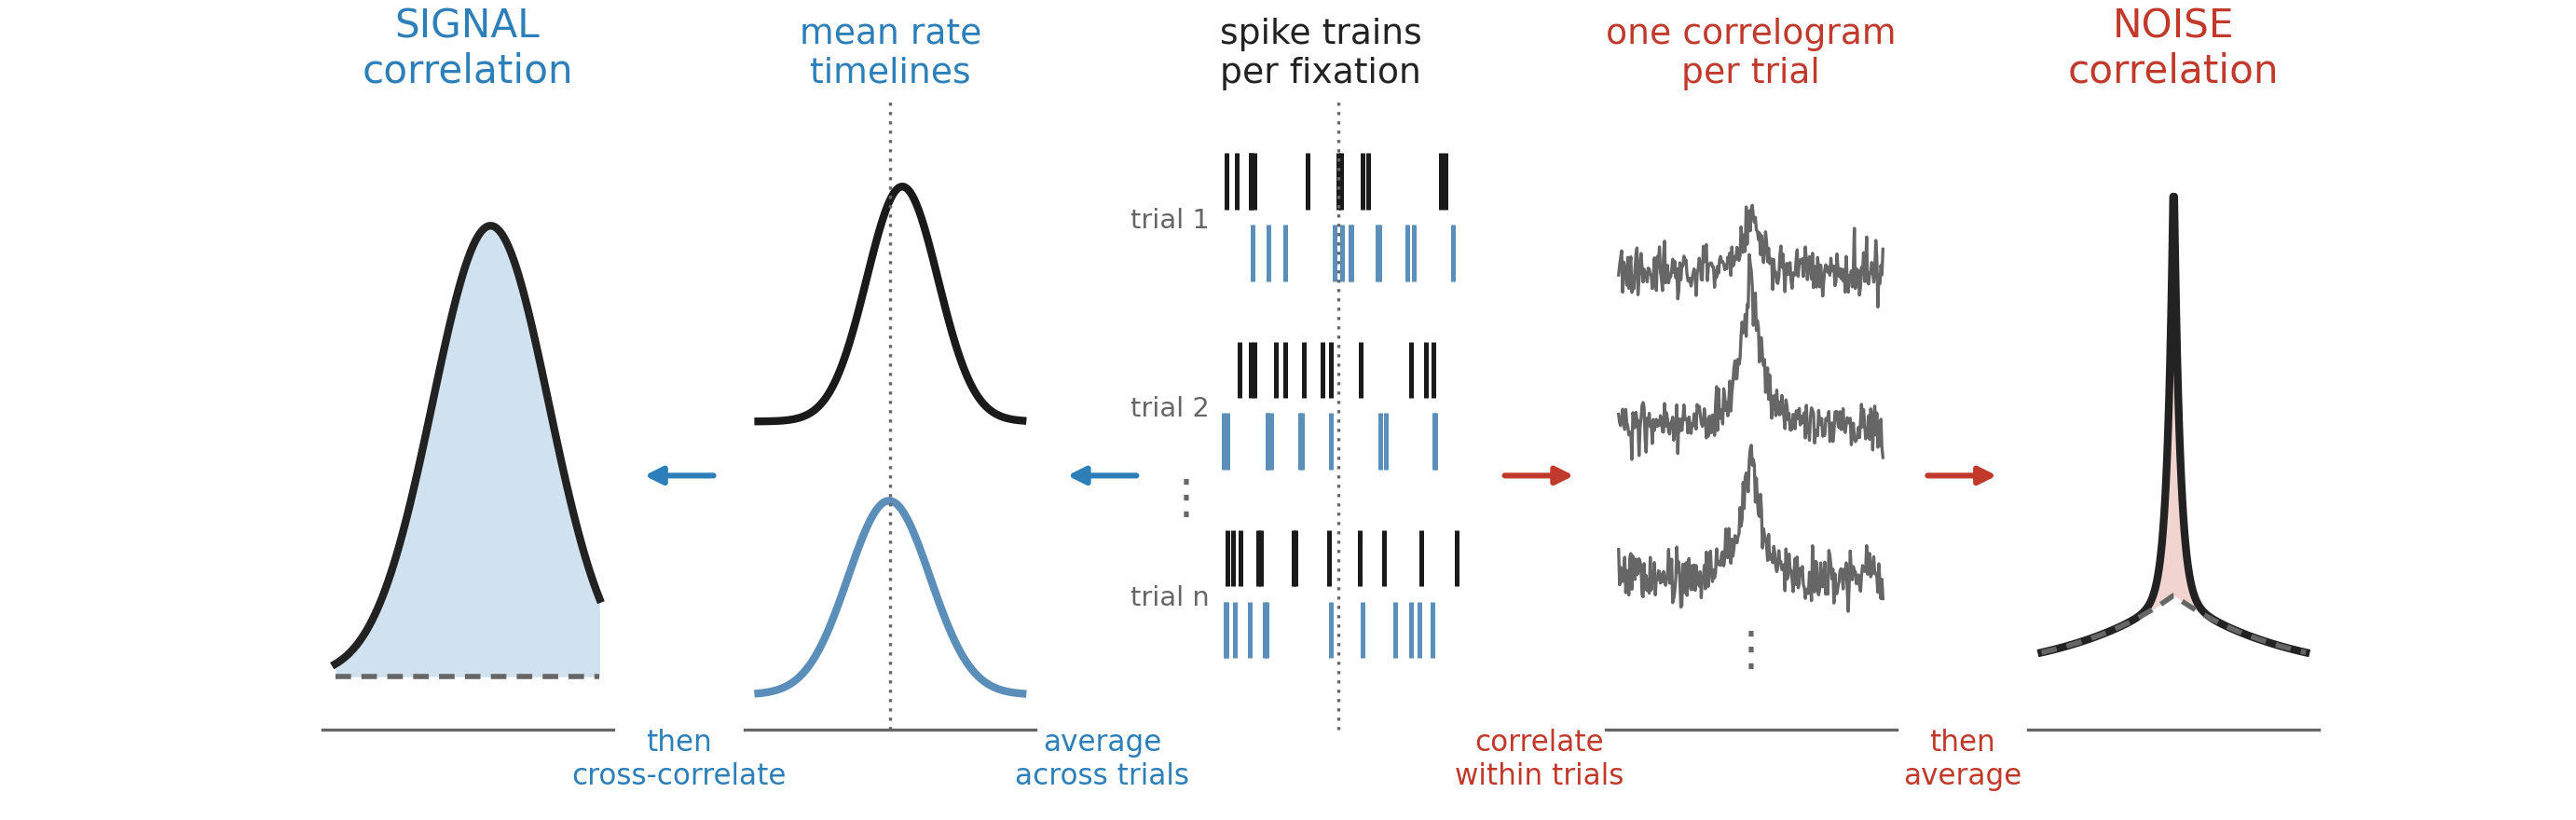

In [2]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

## Results

### What is in the analysis

In [3]:
# --- noise correlation: per-fixation spike trains, circular-shift null -------
noise = psc.load_pair_coordination(CFG_PATH)[0]
noise, dropped = psc.drop_zero_lag_artifact_dates(noise)
noise = noise.loc[noise["both_selective"]].copy()
noise["scope"] = np.where(noise["same_region"], "within_region", "cross_region")
noise_traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
print(f"noise: {len(noise):,} pair-conditions, both units FDR-selective   "
      f"(artifact dates removed: {dropped})")

# --- signal correlation: condition-averaged timelines, cross-session null ----
signal_settings = sc.SignalCorrelationSettings(cfg_path=CFG_PATH)
units, timeline = sc.load_condition_timelines(signal_settings)
signal, signal_lags = sc.build_pair_correlations(units, timeline, signal_settings)
signal_traces = {
    "lags_ms": signal_lags,
    "traces": sc.build_group_traces(signal, signal_settings),
}
print(f"signal: {len(signal):,} pairs from {len(units)} FDR-selective units")

joined = sc.join_with_noise_correlation(
    signal, signal_settings, signal_metric=sc.WINDOW_METRIC
)
correlations = sc.correlate_signal_with_noise(joined)

display(
    signal.groupby(["scope", "region_pair"], observed=True)
    .size().rename("signal_pairs").to_frame()
)

noise: 113,163 pair-conditions, both units FDR-selective   (artifact dates removed: ['01172019', '09272018', '09292018'])


signal: 5,206 pairs from 574 FDR-selective units


signal_pairs
scope         region_pair              
cross_region  accg-bla              752
              accg-dmpfc             43
              bla-dmpfc             847
              bla-ofc               559
within_region accg                  356
              bla                  1786
              dmpfc                 320
              ofc                   543

### Within region

#### Figure 2 — Signal correlation

The cross-session null is subtracted, so zero means "resembles a same-region
unit from another session no more than chance".

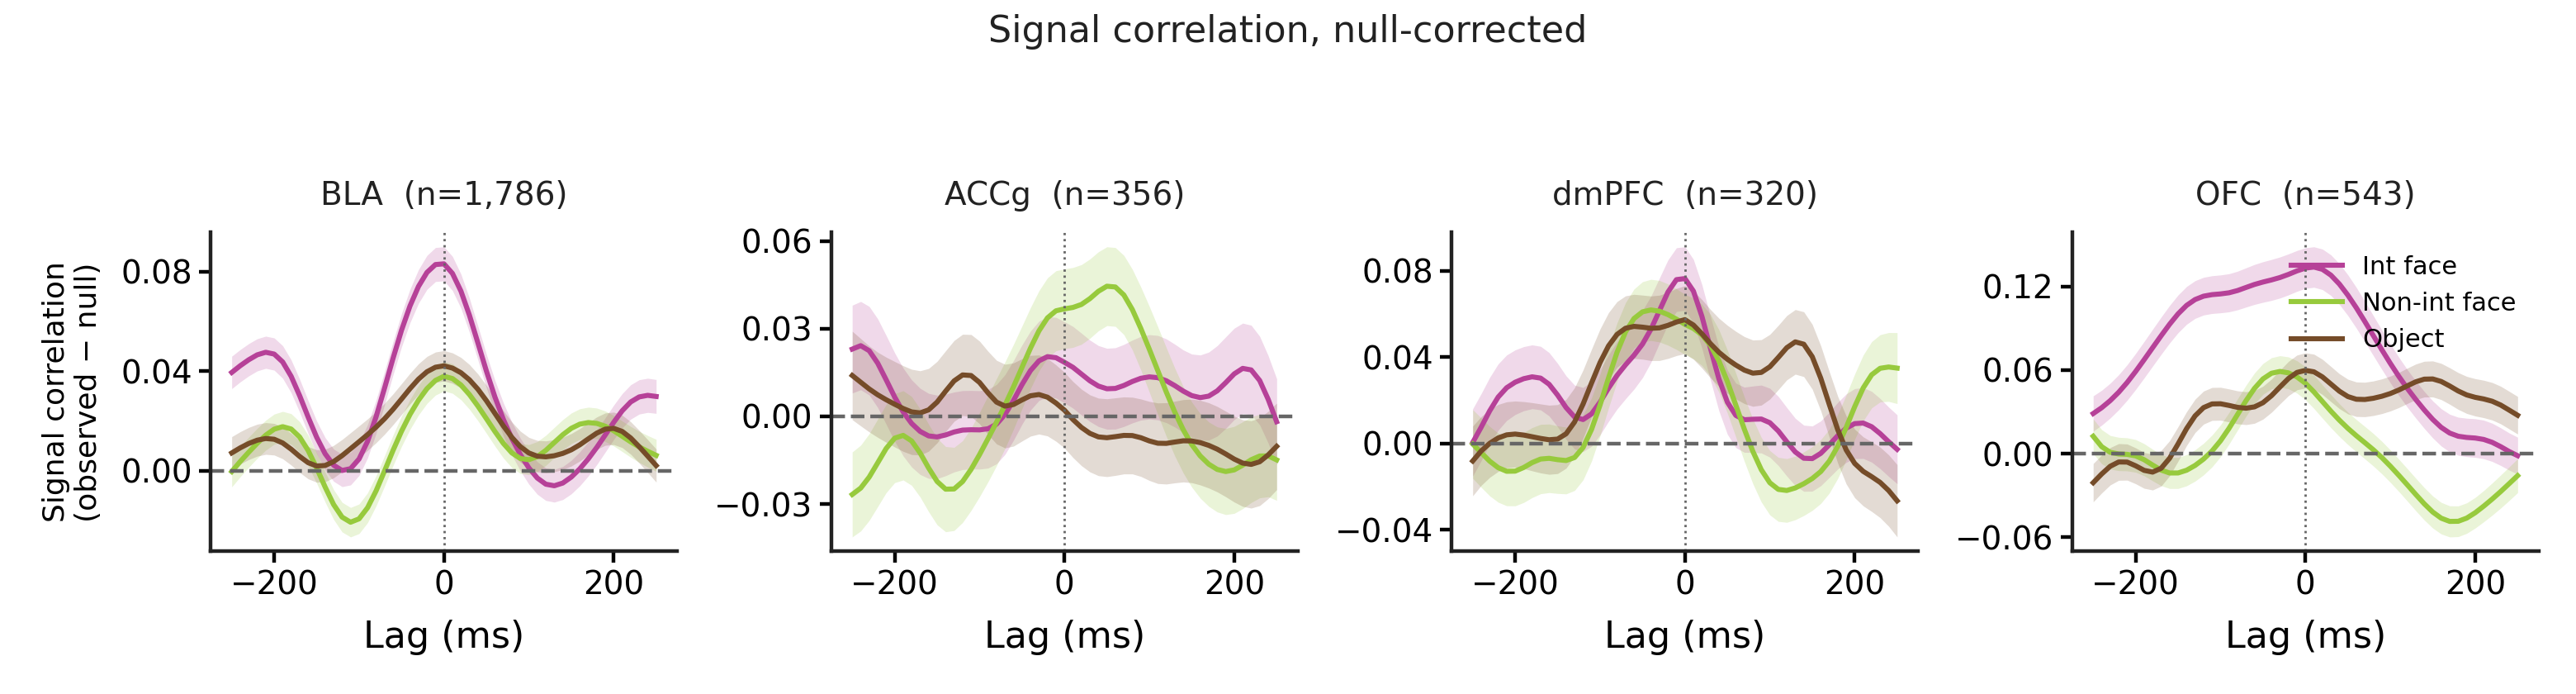

In [4]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="within_region", max_lag_ms=250.0,
    ylabel="Signal correlation\n(observed − null)",
    title="Signal correlation, null-corrected",
    stem="fig02_signal_excess",
)
display(Image(filename=str(paths["png"])))

#### Figure 3 — Noise correlation

Rows are fixation conditions, columns are regions. The gap between the two
curves is the coordination; the observed curve alone is not, since an
unnormalised cross-correlation scales with the product of the two firing rates.

The three rows look alike, which is the result.

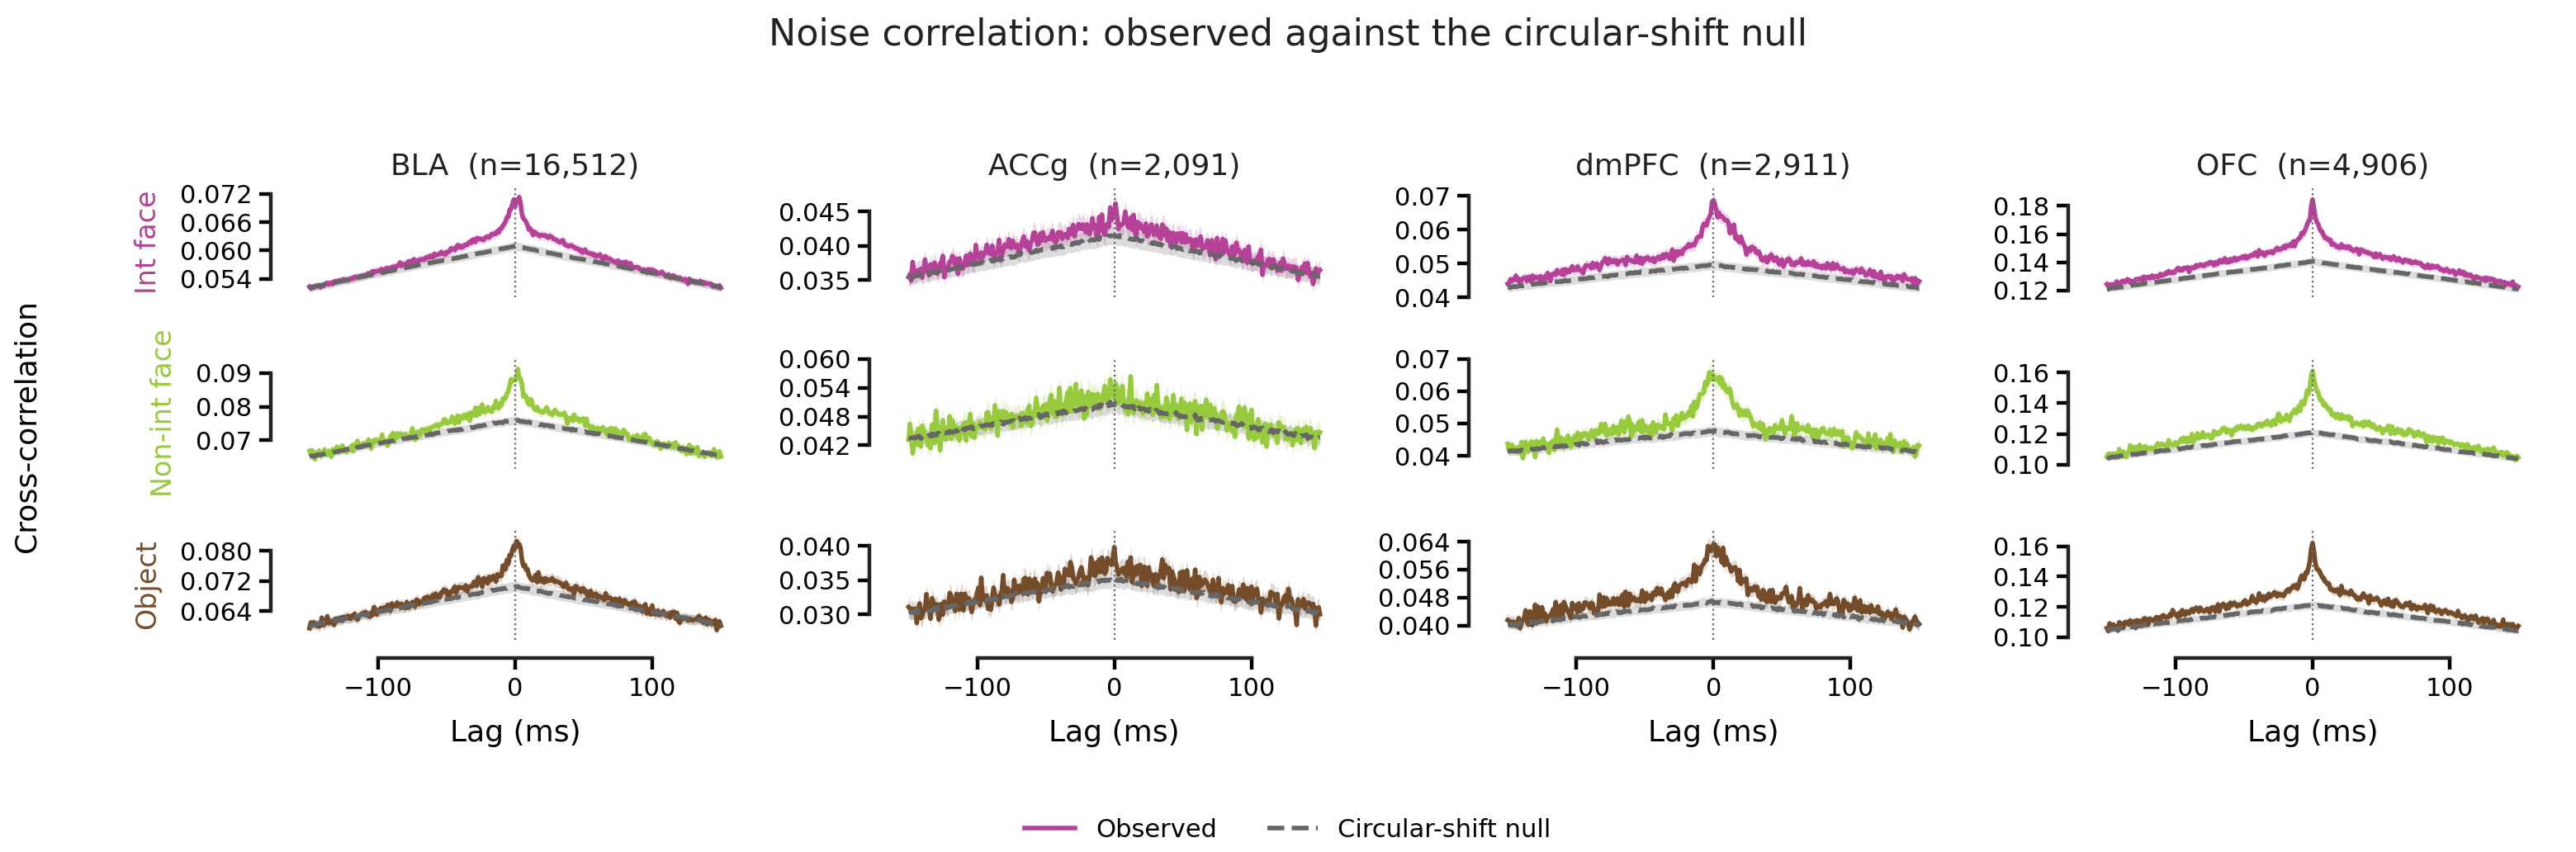

In [5]:
fig, paths = viz.plot_noise_above_null(noise_traces, figs, scope="within_region")
display(Image(filename=str(paths["png"])))

#### Figure 4 — Summary

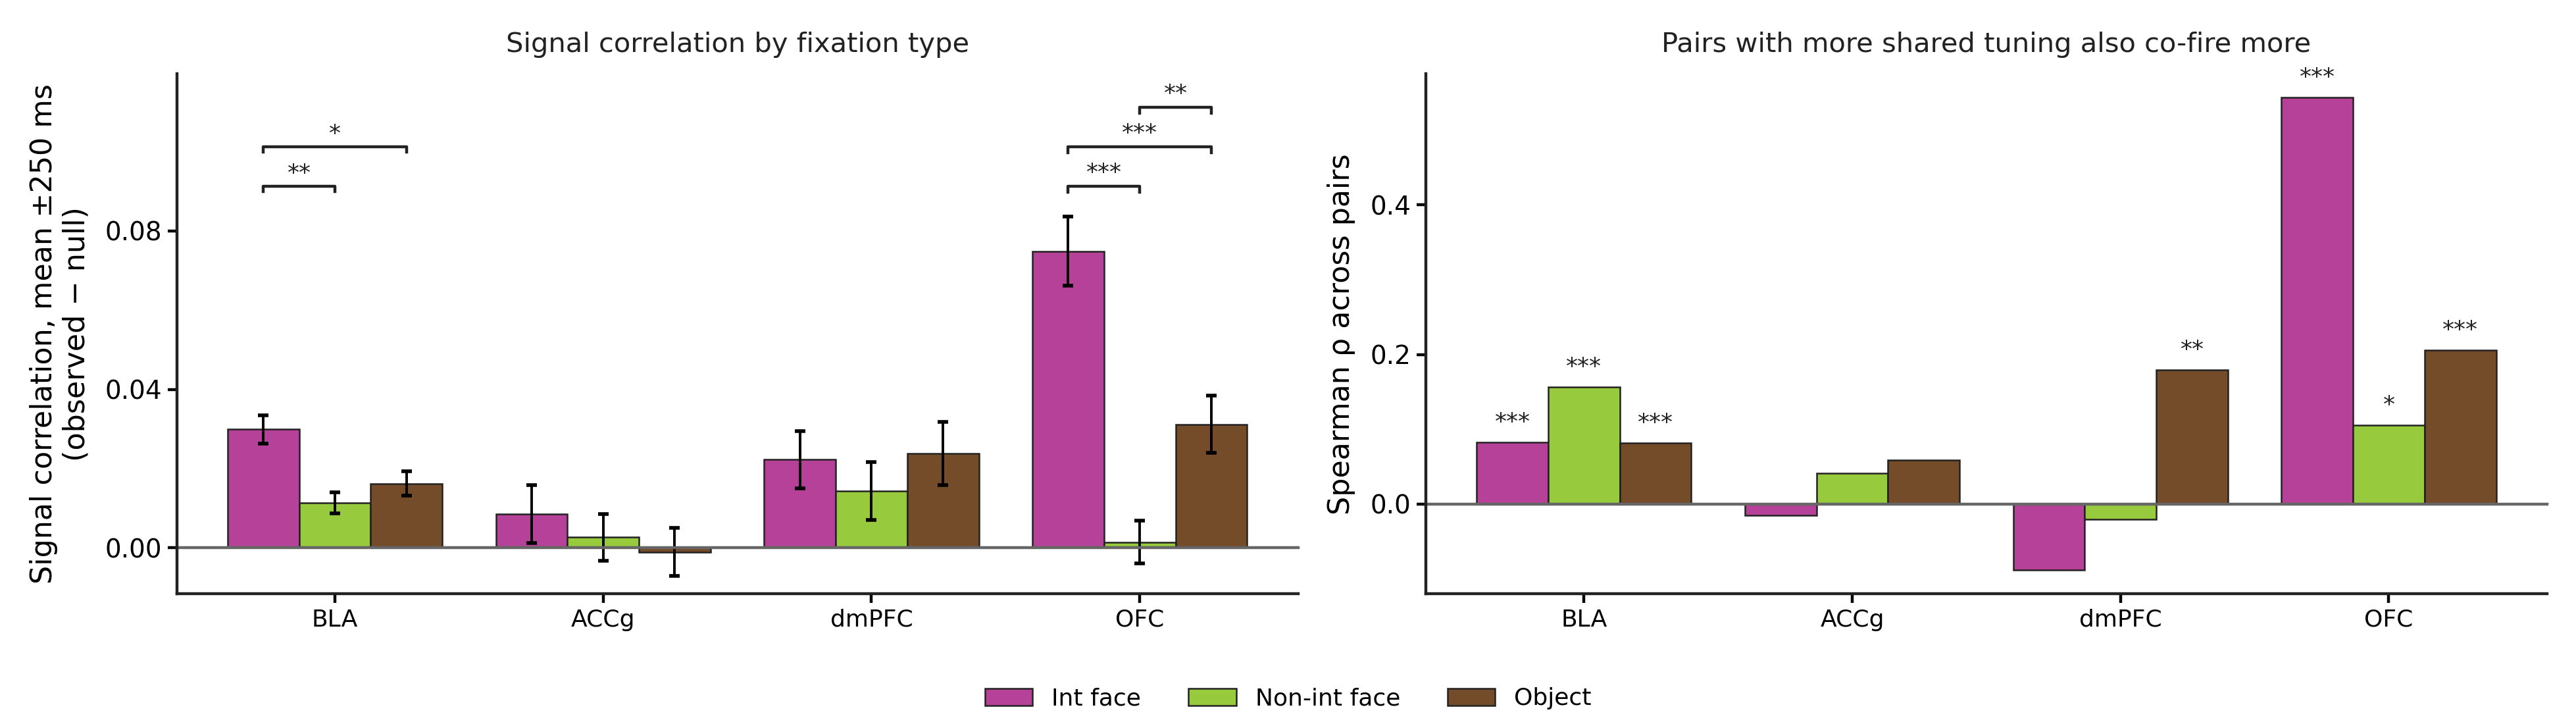

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0085,0.0026,-0.0011
bla,0.0299,0.0113,0.0162
dmpfc,0.0222,0.0143,0.0238
ofc,0.0749,0.0014,0.0312


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,356,0.0059,-0.0112,0.9462,False
1,accg,face_interactive,object,356,0.0096,0.0169,0.9130,False
2,accg,face_non_interactive,object,356,0.0037,0.0506,0.9130,False
3,bla,face_interactive,face_non_interactive,1786,0.0186,0.0705,0.0029,True
4,bla,face_interactive,object,1786,0.0137,0.0448,0.0108,True
5,bla,face_non_interactive,object,1786,-0.0049,0.0034,0.9130,False
6,dmpfc,face_interactive,face_non_interactive,320,0.0079,0.0125,0.9130,False
7,dmpfc,face_interactive,object,320,-0.0016,0.0125,0.9130,False
8,dmpfc,face_non_interactive,object,320,-0.0095,-0.0500,0.9130,False
9,ofc,face_interactive,face_non_interactive,543,0.0735,0.2965,0.0000,True


,region_pair,condition,n_pairs,spearman_rho,p_value
9,accg,face_interactive,276,-0.0147,0.8073
10,accg,face_non_interactive,248,0.0412,0.5188
11,accg,object,273,0.0587,0.3339
12,bla,face_interactive,1714,0.0828,0.0006
13,bla,face_non_interactive,1656,0.1569,0.0000
14,bla,object,1617,0.0820,0.0010
15,dmpfc,face_interactive,320,-0.0884,0.1145
16,dmpfc,face_non_interactive,318,-0.0203,0.7179
17,dmpfc,object,314,0.1797,0.0014
18,ofc,face_interactive,527,0.5436,0.0000


In [6]:
summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
rho = correlations.loc[correlations["scope"] == "within_region"]

fig, paths = viz.plot_summary_bars(summary, contrasts, rho, figs, scope="within_region")
display(Image(filename=str(paths["png"])))

display(
    summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)

display(
    contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)
display(rho.loc[:, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]].round(4))

### Across regions

Only BLA × ACCg, BLA × dmPFC and BLA × OFC are populated enough to report.

#### Figure 5 — Signal correlation

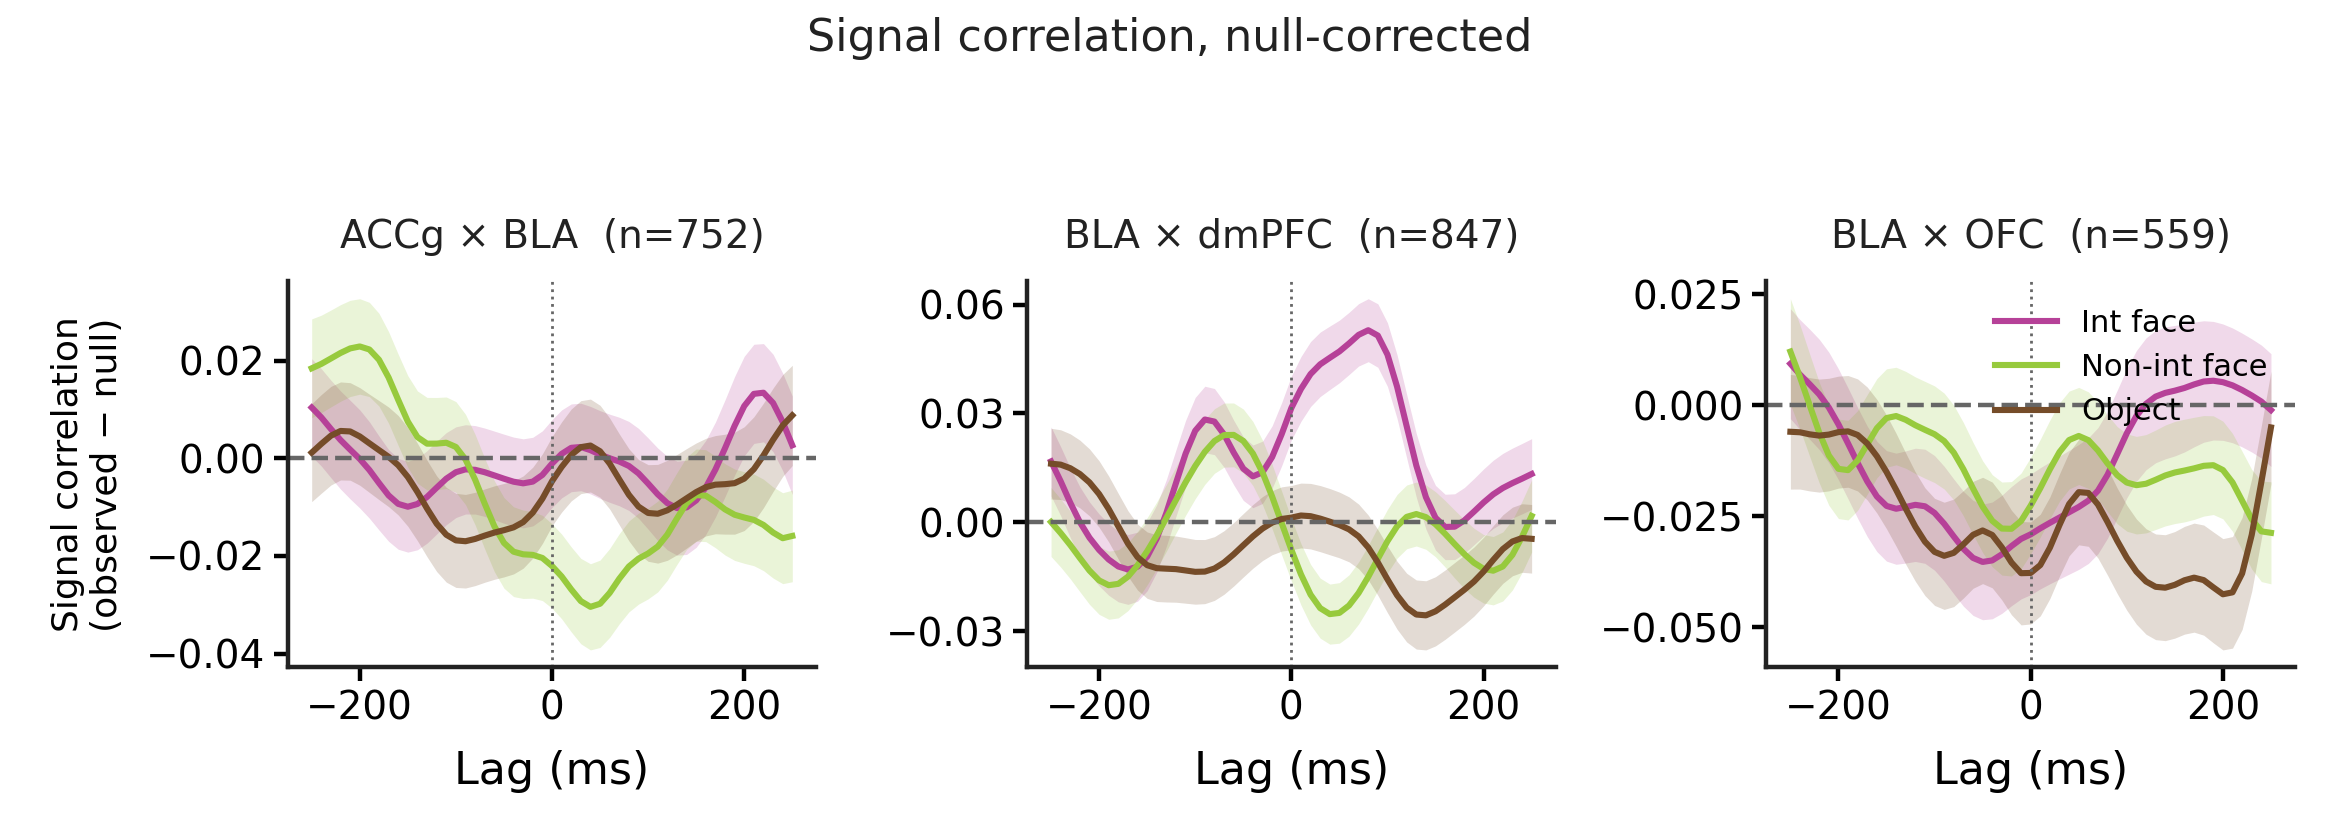

In [7]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="cross_region", max_lag_ms=250.0,
    ylabel="Signal correlation\n(observed − null)",
    title="Signal correlation, null-corrected",
    stem="fig02_signal_excess",
)
display(Image(filename=str(paths["png"])))

#### Figure 6 — Noise correlation

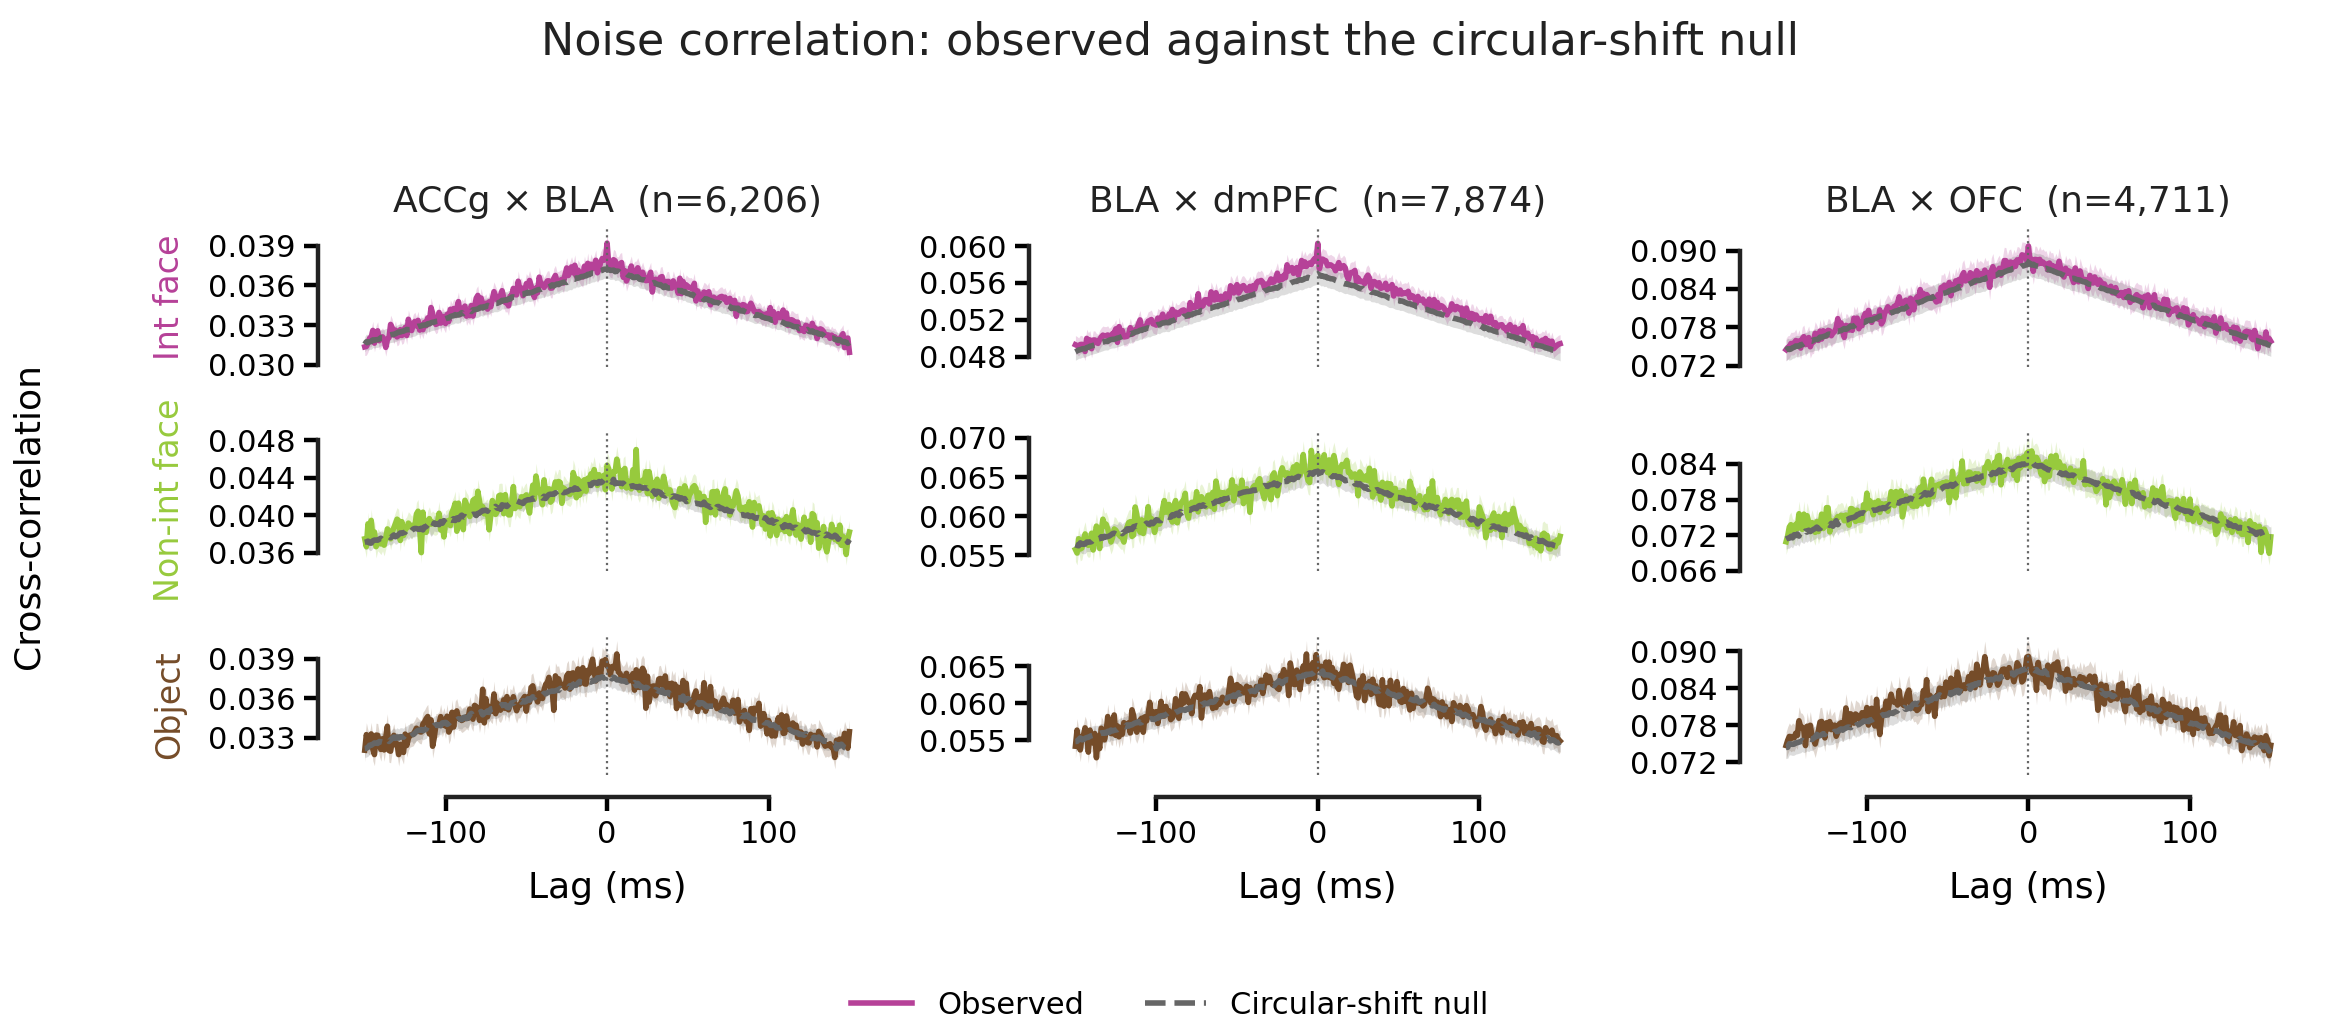

In [8]:
fig, paths = viz.plot_noise_above_null(noise_traces, figs, scope="cross_region")
display(Image(filename=str(paths["png"])))

#### Figure 7 — Summary

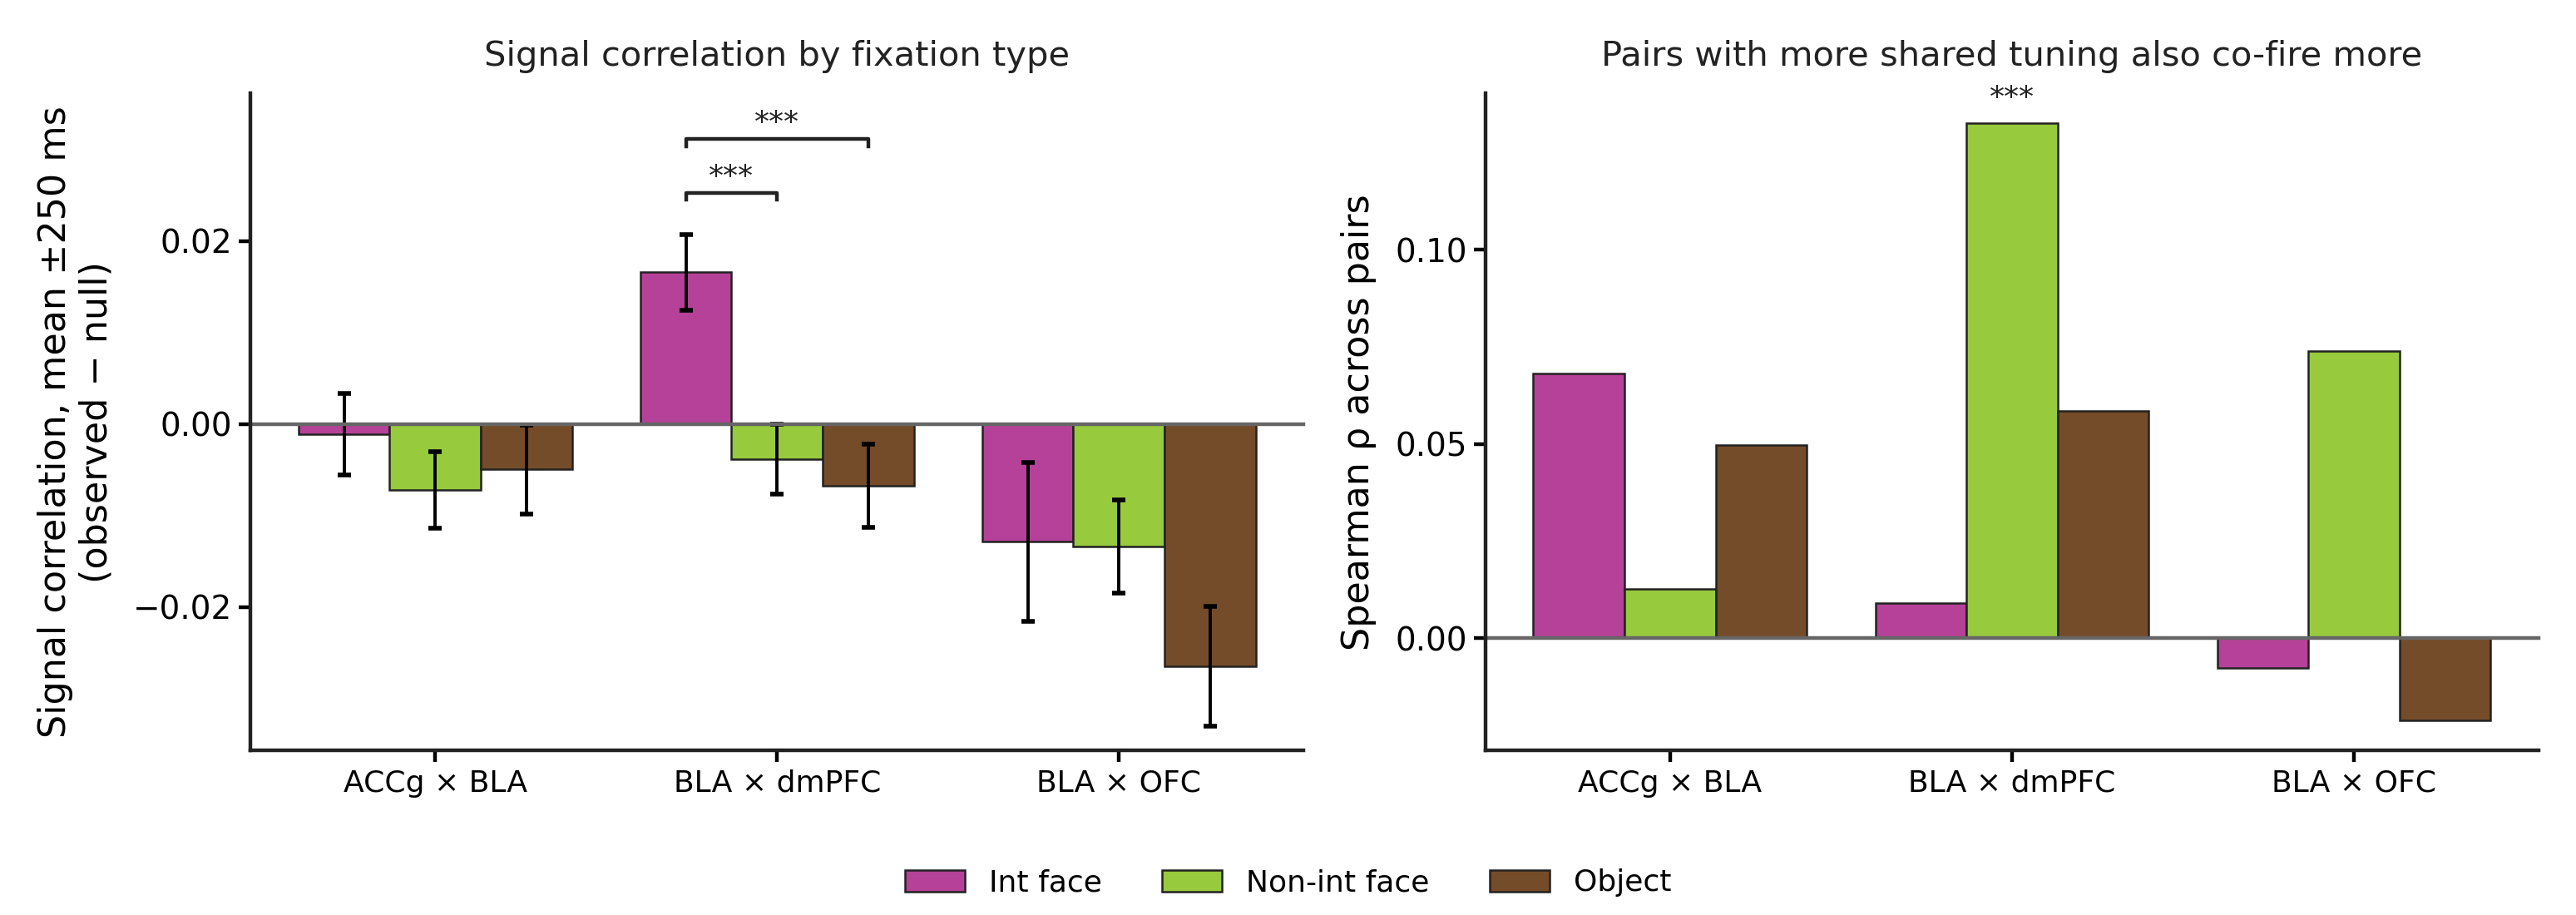

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg-bla,-0.0011,-0.0072,-0.0050
bla-dmpfc,0.0166,-0.0039,-0.0068
bla-ofc,-0.0129,-0.0134,-0.0265


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg-bla,face_interactive,face_non_interactive,752,0.0061,0.0452,0.5120,False
1,accg-bla,face_interactive,object,752,0.0038,0.0532,0.6749,False
2,accg-bla,face_non_interactive,object,752,-0.0023,-0.0293,0.7487,False
3,bla-dmpfc,face_interactive,face_non_interactive,847,0.0205,0.1334,0.0002,True
4,bla-dmpfc,face_interactive,object,847,0.0233,0.1405,0.0002,True
5,bla-dmpfc,face_non_interactive,object,847,0.0029,-0.0106,0.7487,False
6,bla-ofc,face_interactive,face_non_interactive,559,0.0005,-0.0125,0.9056,False
7,bla-ofc,face_interactive,object,559,0.0136,0.0161,0.6749,False
8,bla-ofc,face_non_interactive,object,559,0.0131,0.0304,0.5120,False


,region_pair,condition,n_pairs,spearman_rho,p_value
0,accg-bla,face_interactive,734,0.0682,0.0647
1,accg-bla,face_non_interactive,709,0.0128,0.7342
2,accg-bla,object,713,0.0498,0.1840
3,bla-dmpfc,face_interactive,847,0.0090,0.7937
4,bla-dmpfc,face_non_interactive,814,0.1325,0.0001
5,bla-dmpfc,object,810,0.0585,0.0960
6,bla-ofc,face_interactive,505,-0.0076,0.8652
7,bla-ofc,face_non_interactive,490,0.0740,0.1020
8,bla-ofc,object,491,-0.0212,0.6386


In [9]:
summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
rho = correlations.loc[correlations["scope"] == "cross_region"]

fig, paths = viz.plot_summary_bars(summary, contrasts, rho, figs, scope="cross_region")
display(Image(filename=str(paths["png"])))

display(
    summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)

display(
    contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)
display(rho.loc[:, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]].round(4))

## Discussion

### The fixation-condition effect is in shared tuning, not co-fluctuation

The clearest result is a dissociation. Signal correlation differs between
fixation conditions — interactive face is higher than both other conditions in
BLA and OFC, with rank-biserial effect sizes of 0.09 and 0.25 respectively, and
these survive correction. Noise correlation does not: across all four regions
and all three contrasts the largest effect size is **0.079**, most are below
0.05, and while 8 of 12 reach significance that is a statement about having
9,000 pairs rather than about the neurons.

The two measures are computed from the same spike trains, on the same pairs, in
the same window, against equally conservative nulls. The difference between them
is one step — whether trials are averaged before or after correlating. That the
condition effect appears on one side of that step and not the other is
informative: what interactive fixation changes is **how much two neurons'
average responses resemble each other**, not how tightly they co-fire on any
given fixation.

Framed in population terms, this is a change in the *representation* rather than
in the *noise structure*. It is the less common of the two findings in this
literature, where attention and state effects are usually reported on noise
correlation.

### Both forms of coupling exist, and are regionally organised

Neither result is a null. Noise correlation sits clearly above the circular-shift
null in every region and condition — a null that already preserves each
fixation's spike count and slow envelope, and so credits nothing to shared
excitability. Signal correlation sits clearly above a null built from real,
fixation-locked units of the same region.

Both vary by region, and not in the same way. OFC has the largest signal
correlation and the largest condition effect; BLA has the most pairs and a
smaller but consistent effect; ACCg is the weakest on both measures and is the
one region where non-interactive face rather than interactive face is highest.
dmPFC shows essentially no condition differentiation in signal correlation
despite clear coupling.

### Shared tuning and co-fluctuation are related, but only within a region

Pairs with more shared tuning also co-fire more, within region: OFC interactive
face reaches ρ = 0.35, BLA interactive face ρ = 0.10, dmPFC object ρ = 0.17.
This is not automatic — the two quantities come from different operations and
either can exist without the other — so a positive relationship says the same
local circuitry plausibly produces both.

Across regions the relationship is absent, and so is most of the coupling.
Cross-region noise correlation barely departs from its null, and cross-region
signal correlation is at or below zero for most combinations. The one exception
is **BLA × dmPFC during interactive face**, where signal correlation is
significantly above both other conditions. That this is the only cross-region
combination showing anything, and that it involves BLA and dmPFC specifically,
is worth following up rather than treating as noise — but it is one comparison
among nine and should be replicated before it carries weight.

### Limitations

**Trial-count imbalance is the main threat to the signal-correlation result.**
Interactive-face fixations outnumber the others roughly six to one, so
interactive-face mean timelines are estimated more precisely and correlate
better with anything. The cross-session null does not absorb this: the null
partner shares no tuning, so its correlation sits near zero whatever the
precision. The noise contrasts are trial-count matched and do not carry the
problem; the signal contrasts cannot be, because no matched average exists.
Stratifying by the interactive-to-object trial ratio bounds it directly, and in
the lowest stratum the advantage is near zero — so the reported sizes should be
treated as **upper bounds**. A definitive test requires re-averaging the
per-trial PSTHs at matched trial counts.

**Spearman's correction for attenuation is unavailable here.** It would be the
textbook remedy, but it needs each timeline's reliability, and these means are
smoothed before averaging while the SEMs are not correspondingly reduced, so the
estimate is negative for most units.

**Cross-region coverage is set by the recordings, not by choice.** Every
well-populated cross-region combination involves BLA; ACCg and OFC were never
recorded simultaneously, and dmPFC × OFC comes from ten sessions. The absence of
a cross-region effect is therefore a statement about BLA–frontal pairs, not
about cortico-cortical coupling in general.

**Selective units only.** Restricting to selective units makes the question well
posed but means these results describe the responsive subpopulation. Whether
non-selective pairs show the same architecture is untested here.

**Simultaneity is required by the noise measure but not the signal measure.**
Signal correlation is computed on simultaneously recorded pairs so the two can
be compared pair for pair, but it could in principle be computed across
sessions — indeed that is what the null does. The restriction costs statistical
power on the signal side and should be relaxed if signal correlation is ever the
sole question.

### Conclusion

Simultaneously recorded pairs of selective neurons in BLA, ACCg, dmPFC and OFC
show both shared tuning and trial-by-trial co-fluctuation, each above a
conservative null. Interactive-face fixation modulates the first and not the
second, most strongly in OFC and BLA, and the two forms of coupling are related
within a region but not across regions. What social interaction changes in these
circuits, on this evidence, is what pairs of neurons jointly represent — not how
noisily they represent it.